## Importaciones y carga de csv

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ncaa = pd.read_csv('../datos/raw/College_BasketballPlayers2009-2021.csv', low_memory=False)

In [4]:
ncaa.info()

<class 'pandas.DataFrame'>
RangeIndex: 61061 entries, 0 to 61060
Data columns (total 66 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   player_name                      61061 non-null  str    
 1   team                             61061 non-null  str    
 2   conf                             61061 non-null  str    
 3   GP                               61061 non-null  int64  
 4   Min_per                          61061 non-null  float64
 5   Ortg                             61061 non-null  float64
 6   usg                              61061 non-null  float64
 7   eFG                              61061 non-null  float64
 8   TS_per                           61061 non-null  float64
 9   ORB_per                          61061 non-null  float64
 10  DRB_per                          61061 non-null  float64
 11  AST_per                          61061 non-null  float64
 12  TO_per                       

In [5]:
ncaa.describe()

,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,AST_per,TO_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,Unnamed: 65
count,61061.000000,61061.00000,61061.000000,61061.000000,61061.000000,61061.000000,61061.00000,61061.000000,61061.000000,61061.000000,...,61016.000000,61016.000000,61023.000000,61023.000000,61023.000000,61023.000000,61023.000000,61023.000000,61023.000000,61016.000000
mean,22.797760,37.12839,91.666396,18.126341,44.500768,47.584212,5.54225,12.704242,10.808699,20.225856,...,-2.088743,-0.449119,0.764618,1.897561,2.662179,1.072777,0.529446,0.280996,5.773579,5.384933
std,10.166805,28.05805,30.963736,6.253742,18.431761,17.640613,9.30561,10.755123,9.362704,12.318765,...,6.237674,3.336297,0.734824,1.483689,2.097767,1.169677,0.469614,0.414885,4.947872,5.581653
min,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,-141.539000,-100.984000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,9.30000,83.900000,14.500000,40.000000,43.800000,1.80000,8.400000,4.600000,14.700000,...,-4.426910,-1.737988,0.222200,0.703200,1.000000,0.222200,0.157900,0.000000,1.571400,0.326832
50%,27.000000,35.60000,97.100000,18.100000,47.700000,50.850000,4.30000,11.900000,9.000000,19.100000,...,-1.578180,-0.320310,0.538500,1.636400,2.260900,0.677400,0.424200,0.133300,4.483900,4.609915
75%,31.000000,62.00000,106.900000,21.800000,53.300000,56.110000,8.10000,16.100000,15.000000,24.400000,...,0.999816,1.064795,1.103400,2.771400,3.828600,1.533300,0.794100,0.363600,9.064500,8.500773
max,41.000000,98.00000,834.000000,50.000000,150.000000,150.000000,1576.60000,1385.000000,100.000000,100.000000,...,225.485000,78.985500,5.933300,11.545500,15.000000,10.000000,4.000000,5.258100,30.090900,127.274000


In [6]:
ncaa[["player_name","pick"]].head(10)

,player_name,pick
0,DeAndrae Ross,NaN
1,Pooh Williams,NaN
2,Jesus Verdejo,NaN
3,Mike Hornbuckle,NaN
4,Anthony Brown,NaN
5,Nick Rodgers,NaN
6,Dana Smith,NaN
7,Matt Beck,NaN
8,Justin Drummond,NaN
9,Jamal Smith,NaN


La target será la columna "pick", pero ya viendo sus primeros valores se puede intuir un problema: los valores nulos.

Miro cuántos registros tienen NaN en esta columna y cuántos sí tienen un valor de elección de draft.

In [7]:
print(f"Registros con pick: {ncaa['pick'].notna().sum()}")
print()
print(f"Registros sin pick: {ncaa['pick'].isna().sum()}")

Registros con pick: 1435

Registros sin pick: 59626


Existen más de 59.000 registros con valores nulos, pero en este caso tiene sentido, ya que eso significa que no fueron seleccionados por ningún equipo. Esto es lógico, ya que de todos los jugadores universitarios, lo normal es no ser seleccionado. Solamente los mejores lo son.

Ahora, también quiero ver cuántos registros son únicos.

In [8]:
print(ncaa['player_name'].nunique())

25719


## Busco y trabajo los valores nulos

In [9]:
# Filtrar columnas que tienen más de 0 nulos
columnas_con_nulos = ncaa.isnull().sum()
print(columnas_con_nulos[columnas_con_nulos > 0])

yr                                   294
ht                                   111
num                                 4786
Rec Rank                           42591
ast/tov                             4727
rimmade                             6329
rimmade+rimmiss                     6329
midmade                             6329
midmade+midmiss                     6329
rimmade/(rimmade+rimmiss)          10110
midmade/(midmade+midmiss)          10385
dunksmade                           6329
dunksmiss+dunksmade                 6329
dunksmade/(dunksmade+dunksmiss)    33510
pick                               59626
drtg                                  45
adrtg                                 45
dporpag                               45
stops                                 45
bpm                                   45
obpm                                  45
dbpm                                  45
gbpm                                  45
mp                                    38
ogbpm           

Estas son todas las columnas que tienen valores nulos, habrá que ir trabajándolas a partir de ahora. Lo primero es buscar información de cada columna y ver si puede permanecer o la puedo borrar del dataframe.

"Rec Rank", "num", "unnamed 65", "type" y las que tienen totales de tiro puedo eliminarlas sin ningún problema.

In [10]:
# creo una lista con las columnas que quiero eliminar
cols_eliminar = [
    'Rec Rank', 'num', 'Unnamed: 65', 'type',
    'dunksmade/(dunksmade+dunksmiss)',
    'dunksmade', 'dunksmiss+dunksmade',
    'rimmade+rimmiss', 'midmade+midmiss'
]

# elimino esas columnas
ncaa = ncaa.drop(columns=cols_eliminar)

Ahora trabajo las demás columnas con valores nulos.

In [11]:
# la columna 'Unnamed: 64' es la posición del jugador, por tanto la renombro
ncaa = ncaa.rename(columns={'Unnamed: 64': 'posicion'})

In [12]:
# sustituyo los NaN en posicion por "desconocido"
ncaa['posicion'] = ncaa['posicion'].fillna('desconocido')

In [13]:
# Calculamos la mediana global (de todos los años) de las variables de efectividad bajo el aro y en media distancia
mediana_global_rim = ncaa['rimmade/(rimmade+rimmiss)'].median()
mediana_global_mid = ncaa['midmade/(midmade+midmiss)'].median()

# Primero rellenamos con mediana por año (funciona para 2010-2021)
ncaa['rimmade/(rimmade+rimmiss)'] = ncaa['rimmade/(rimmade+rimmiss)'].fillna(ncaa.groupby('year')['rimmade/(rimmade+rimmiss)'].transform('median'))
ncaa['midmade/(midmade+midmiss)'] = ncaa['midmade/(midmade+midmiss)'].fillna(ncaa.groupby('year')['midmade/(midmade+midmiss)'].transform('median'))

# Los que siguen siendo NaN (2009) los rellenamos con la mediana global
ncaa['rimmade/(rimmade+rimmiss)'] = ncaa['rimmade/(rimmade+rimmiss)'].fillna(mediana_global_rim)
ncaa['midmade/(midmade+midmiss)'] = ncaa['midmade/(midmade+midmiss)'].fillna(mediana_global_mid)


In [14]:
# si hay NaN en las columnas 'dunksmade', 'rimmade', 'midmade', se asume que el valor es 0
for col in ['dunksmade', 'rimmade', 'midmade']:
    if col in ncaa.columns:
        ncaa[col] = ncaa[col].fillna(0)

In [15]:
# se rellenan los NaN en la columna 'ast/tov' (relación entre asistencias y pérdidas de balón) con la mediana por año
ncaa['ast/tov'] = ncaa.groupby('year')['ast/tov'].transform(lambda x: x.fillna(x.median()))


In [16]:
# se rellenan los NaN en las columnas 'yr' y 'ht' con la moda (valor más frecuente)
ncaa['yr'] = ncaa['yr'].fillna(ncaa['yr'].mode()[0])
ncaa['ht'] = ncaa['ht'].fillna(ncaa['ht'].mode()[0])

In [17]:
# se rellenan los NaN en las columnas 'pts', 'ast', 'treb', etc. con la mediana por año
stats_basicas = ['pts', 'ast', 'treb', 'stl', 'blk', 'oreb', 'dreb', 'mp',
                 'bpm', 'obpm', 'dbpm', 'gbpm', 'ogbpm', 'dgbpm',
                 'drtg', 'adrtg', 'dporpag', 'stops']
for col in stats_basicas:
    if col in ncaa.columns:
        ncaa[col] = ncaa.groupby('year')[col].transform(lambda x: x.fillna(x.median()))

Compruebo si me quedan valores nulos.

In [18]:
# Filtrar columnas que tienen más de 0 nulos
columnas_con_nulos = ncaa.isnull().sum()
print(columnas_con_nulos[columnas_con_nulos > 0])

pick    59626
dtype: int64


Perfecto, ahora solamente me quedan los nulos de pick. Lo que haré será sustituir los valores por debajo de 30 por R1 (ronda 1), los que están entre 30 y 60 por R2 y los NaN por ND (no drafteado). Introduzco los valores en una nueva columna llamada "ronda".

In [19]:
# Columna 'ronda' como texto: R1, R2, ND
ncaa['ronda'] = ncaa['pick'].apply(lambda x: 'R1' if x <= 30 else ('R2' if x <= 60 else 'ND') if pd.notna(x) else 'ND')

# Columna 'ronda_num' como número: ND=0, R2=1, R1=2
# Cuanto mayor el número, más valorado es el jugador
ncaa['ronda_num'] = ncaa['ronda'].map({'ND': 0, 'R2': 1, 'R1': 2})

# Comprobamos
print("Distribución del target:\n")
print(ncaa['ronda'].value_counts())
print()
print(ncaa[['ronda', 'ronda_num']].drop_duplicates().sort_values('ronda_num'))

Distribución del target:

ronda
ND    59626
R2      812
R1      623
Name: count, dtype: int64

    ronda  ronda_num
0      ND          0
33     R2          1
103    R1          2


## Datos corruptos

La columna "ht" tiene un formato corrupto. Representa la altura, pero tiene un formato de fecha erróneo. Tengo que convertirla a centímetros para poder utilizarla.

In [20]:
# Vemos todos los valores únicos de ht para entender el patrón real
print(ncaa['ht'].value_counts().sort_index())

ht
-          241
0           19
1-Jul      228
1-Jun     3830
1-May        2
10-Jun    2751
10-May    1458
11-Jun    1229
11-May    1614
2-Jul       94
2-Jun     5033
2-May        4
3-Jul       45
3-Jun     5594
3-May        3
4-Jul       14
4-Jun     5849
4-May        4
5-Apr        1
5-Jul        4
5-Jun     5886
5-May        8
6'4          1
6-Jul        7
6-Jun     5607
6-May       45
7-Jun     6193
7-May      103
8-Jun     5961
8-May      258
9-Jun     4361
9-May      623
Apr-00      20
Fr           1
Jr           2
Jul-00     725
Jun-00    3242
So           1
Name: count, dtype: int64


In [21]:
def convertir_altura(ht):
    try:
        partes = str(ht).split('-')
        
        meses = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
                 'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
        
        # Caso "Jun-00" -> 6 pies 0 pulgadas
        if partes[0] in meses:
            pies = meses[partes[0]]
            pulgadas = 0
        # Caso "1-Jun" -> 6 pies 1 pulgada
        else:
            pulgadas = int(partes[0])
            pies = meses[partes[1]]
        
        return round(pies * 30.48 + pulgadas * 2.54, 1)
    except:
        return None

ncaa['altura_cm'] = ncaa['ht'].apply(convertir_altura)

print(ncaa[['ht', 'altura_cm']].drop_duplicates().sort_values('altura_cm'))

           ht  altura_cm
2654   Apr-00      121.9
26516   5-Apr      134.6
18090   1-May      154.9
35552   2-May      157.5
1369    3-May      160.0
12358   4-May      162.6
3970    5-May      165.1
613     6-May      167.6
435     7-May      170.2
501     8-May      172.7
54      9-May      175.3
32     10-May      177.8
39     11-May      180.3
7      Jun-00      182.9
5       1-Jun      185.4
0       2-Jun      188.0
16      3-Jun      190.5
1       4-Jun      193.0
6       5-Jun      195.6
8       6-Jun      198.1
21      7-Jun      200.7
4       8-Jun      203.2
13      9-Jun      205.7
35     10-Jun      208.3
20     11-Jun      210.8
126    Jul-00      213.4
674     1-Jul      215.9
663     2-Jul      218.4
1470    3-Jul      221.0
4363    4-Jul      223.5
461     5-Jul      226.1
25682   6-Jul      228.6
1086        -        NaN
6389       So        NaN
6994       Jr        NaN
8963       Fr        NaN
9269      6'4        NaN
16484       0        NaN


In [22]:
# los valores que no se pudieron modificar (Jr, Fr, 0...) los relleno con la mediana
ncaa['altura_cm'] = ncaa['altura_cm'].fillna(ncaa['altura_cm'].median())

# compruebo que no quedan NaN y veo el rango final
print(f"NaN restantes: {ncaa['altura_cm'].isna().sum()}")
print(f"Altura mínima: {ncaa['altura_cm'].min()} cm")
print(f"Altura máxima: {ncaa['altura_cm'].max()} cm")
print(f"Altura media: {ncaa['altura_cm'].mean():.1f} cm")

NaN restantes: 0
Altura mínima: 121.9 cm
Altura máxima: 228.6 cm
Altura media: 195.2 cm


## EDA

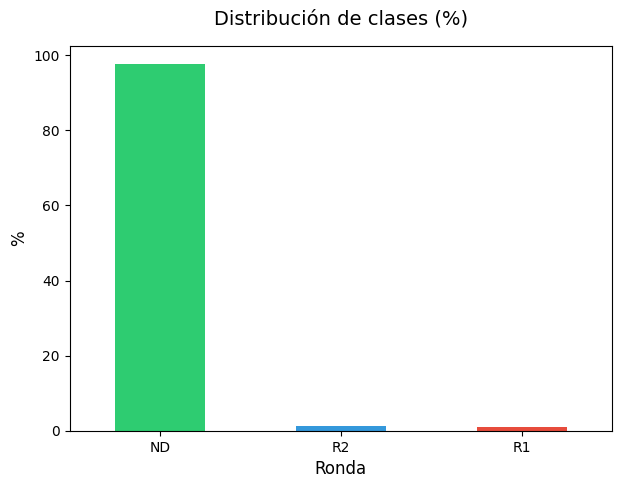

In [23]:
# creo una única figura y un solo eje
fig, ax = plt.subplots(figsize=(7, 5))

# gráfico de barras con el porcentaje de cada clase
(ncaa['ronda'].value_counts() / len(ncaa) * 100).plot(
    kind='bar', 
    ax=ax, 
    color=['#2ecc71', '#3498db', '#e74c3c']
)

# configuración de títulos y etiquetas sobre el único eje
ax.set_title('Distribución de clases (%)', fontsize=14, pad=15)
ax.set_xlabel('Ronda', fontsize=12)
ax.set_ylabel('%', fontsize=12)
ax.tick_params(axis='x', rotation=0);

El desbalanceo de clases es más que evidente. Esto me indica que cuando empiece a entrenar los modelos, tendré que recortar los registros con ND para poder tener una predicción menos sesgada.

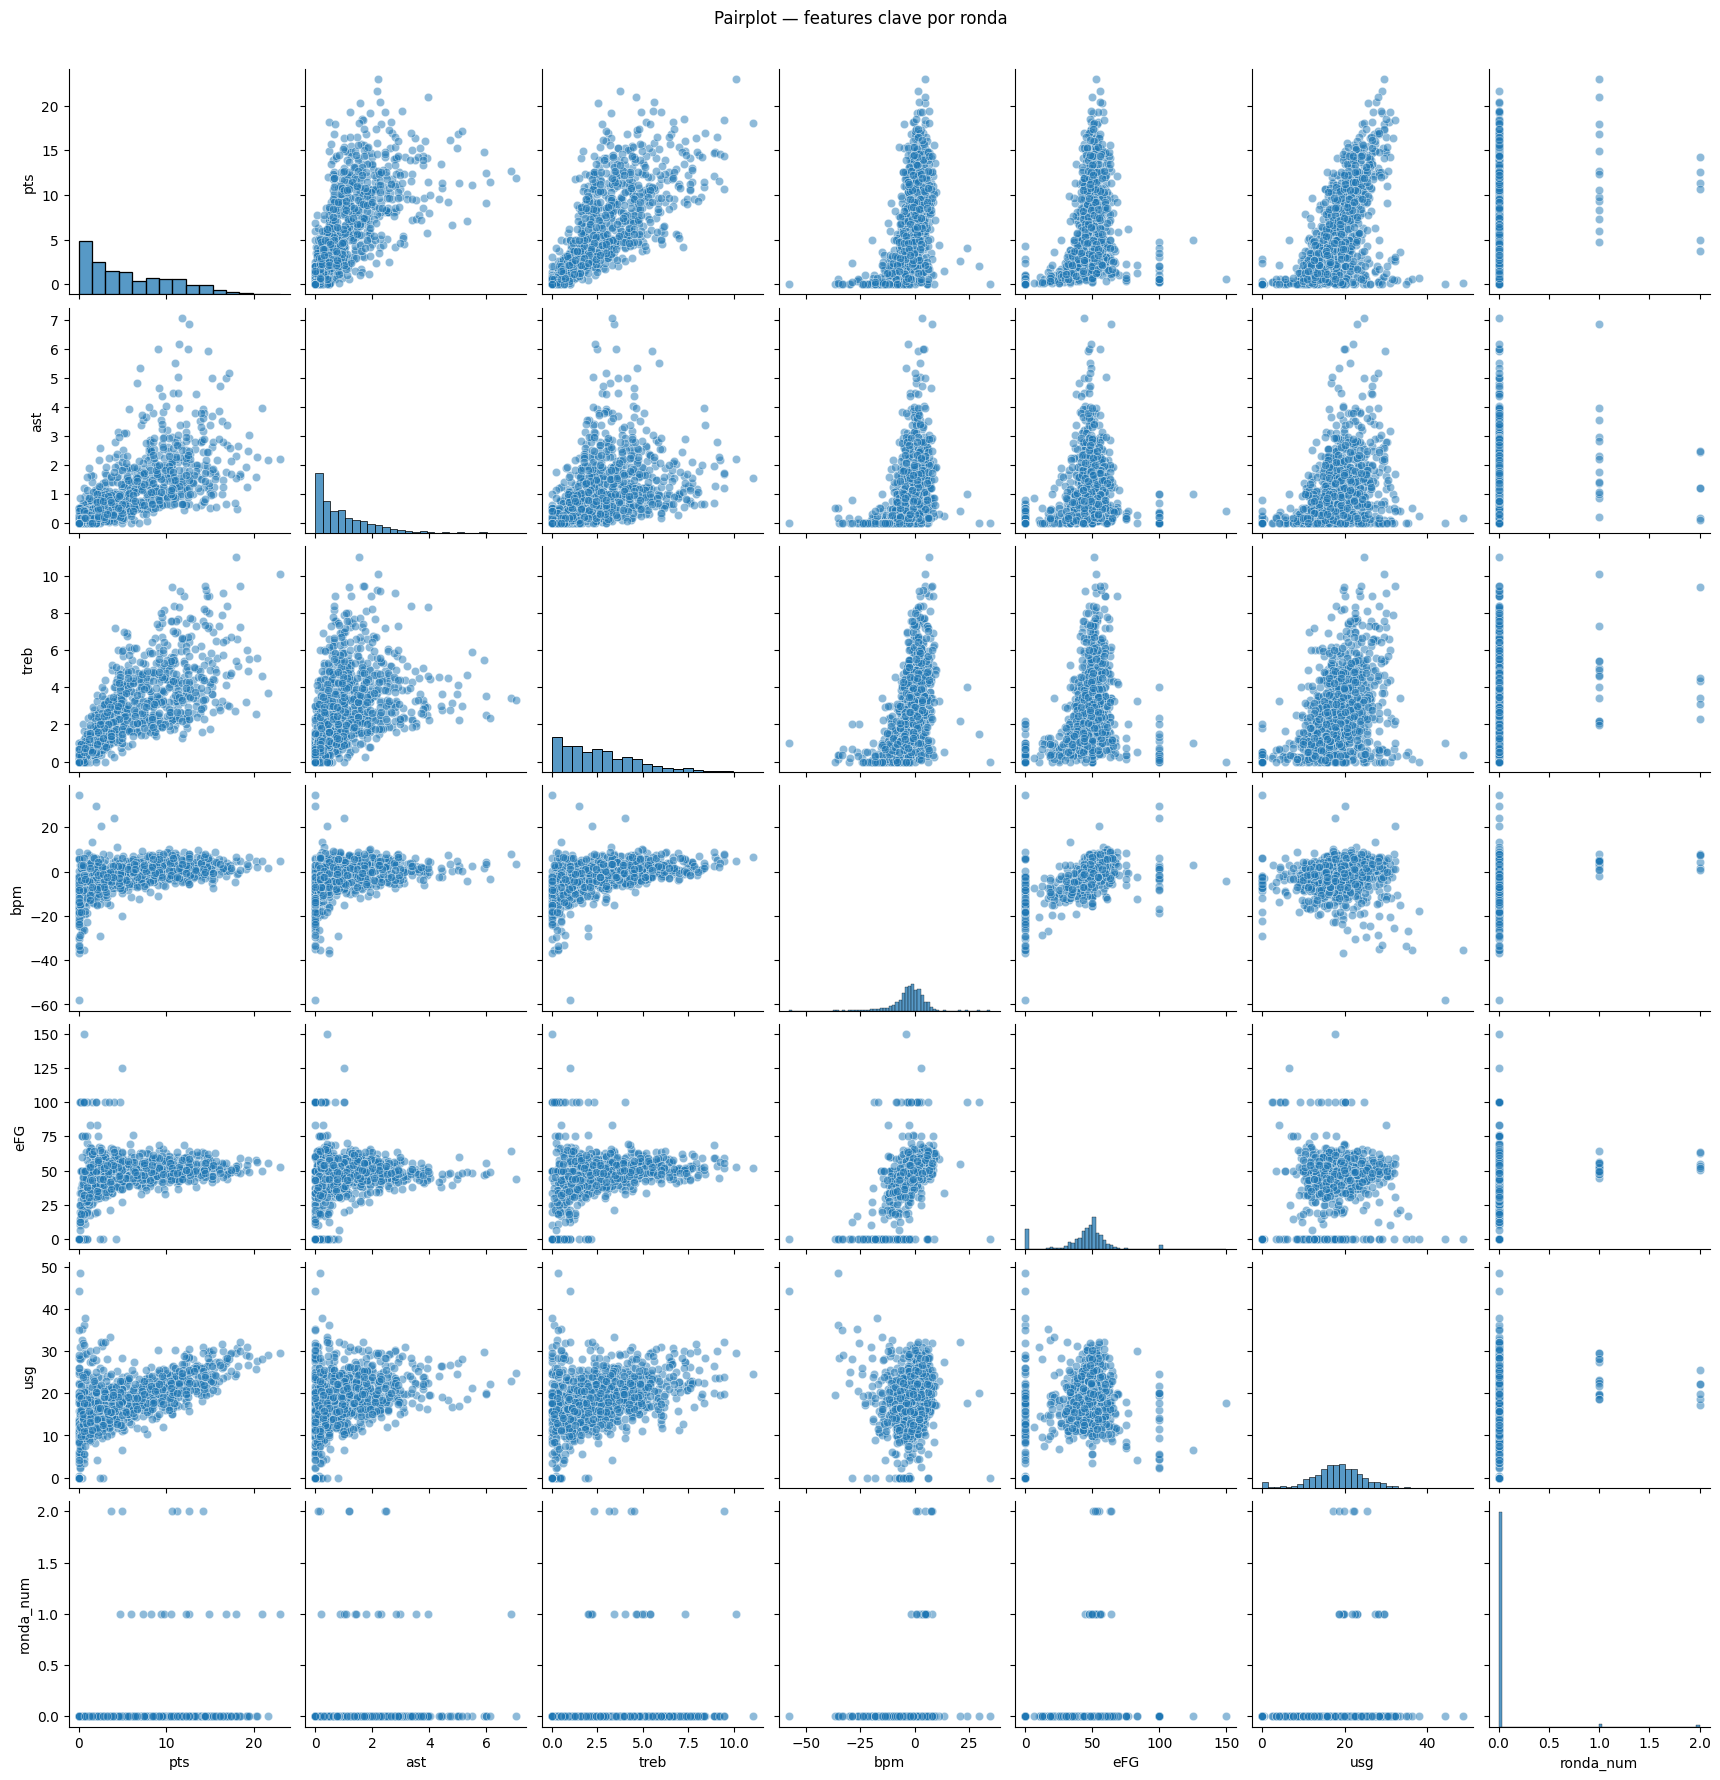

In [24]:
# selecciono variables predictoras que pueden ser interesantes
features_pairplot = ['pts', 'ast', 'treb', 'bpm', 'eFG', 'usg', 'ronda_num']

# uso una muestra de 1000 filas para que no tarde mucho en crear el gráfico
muestra = ncaa[features_pairplot].sample(1000, random_state=42)

# el pairplot muestra la relación entre cada par de variables
# la diagonal muestra la distribución de cada variable
sns.pairplot(muestra, plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot — features clave por ronda', y=1.02);

Se aprecia claramente que pts, ast, treb y bpm tienen valores más altos cuando ronda_num es 1 o 2 (R2 y R1). Es decir, los jugadores drafteados destacan en esas stats.

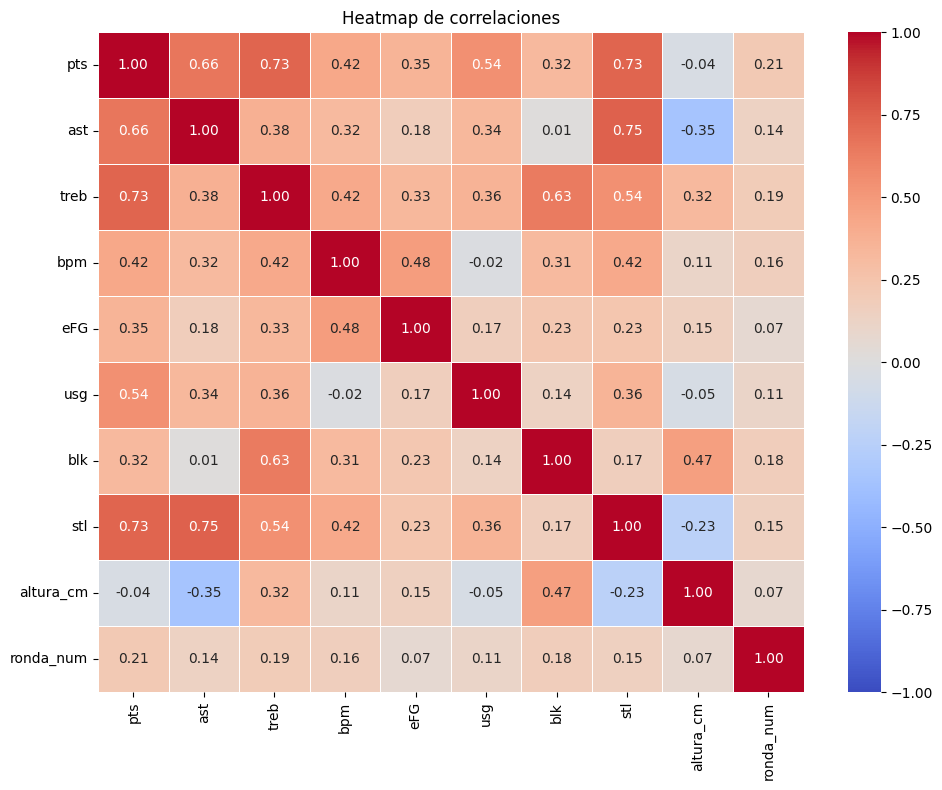

In [25]:
# selecciono variables para visualizar el heatmap
variables_heatmap = ['pts', 'ast', 'treb', 'bpm', 'eFG', 'usg', 'blk', 'stl', 'altura_cm', 'ronda_num']

# calculo la matriz de correlación entre todas las features
correlaciones = ncaa[variables_heatmap].corr()

# dibujo el heatmap
# annot=True muestra el número de correlación en cada celda
# cmap='coolwarm': azul = correlación negativa, rojo = correlación positiva
plt.figure(figsize=(10, 8))
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Heatmap de correlaciones')
plt.tight_layout();

Respecto al target (ronda_num), las correlaciones más altas son pts (0.21), treb (0.19) y stl (0.15). No son correlaciones altísimas, pero tiene sentido — ser drafteado no depende solo de una stat sino de la combinación de todas.

Cosas interesantes entre variables:

* pts y stl correlacionan muy fuerte (0.73) — los jugadores que más anotan también roban más
* ast y stl también (0.75) — los bases dominan ambas
* blk y treb correlacionan bien (0.63) — los pívots tapan y rebotan
* altura_cm y ast correlación negativa (-0.35) — los jugadores altos dan pocas asistencias, lógico
* bpm y eFG (0.48) — los jugadores más eficientes tienen mejor impacto global

Conclusión clave: ninguna variable por sí sola predice bien el draft. El modelo necesitará combinarlas todas, lo que justifica usar XGBoost o similar en lugar de algo simple.

## Ingeniería de variables antes de los modelos

Me quedo solo con un registro de cada jugador (en el dataset original hay un registro por temporada, es decir, si un jugador jugó tres temporadas, hay tres registros)

In [26]:
# ordeno por jugador y año para asegurarnos de que el más reciente queda el último
ncaa = ncaa.sort_values(['player_name', 'year'])

# me quedo solo con la última fila de cada jugador (su temporada más reciente)
ncaa = ncaa.drop_duplicates(subset='player_name', keep='last')

# compruebo
print(f"Registros tras filtrar última temporada: {len(ncaa)}")
print(f"\nDistribución del target:\n{ncaa['ronda'].value_counts()}")

Registros tras filtrar última temporada: 25719

Distribución del target:
ronda
ND    25098
R1      322
R2      299
Name: count, dtype: int64


Miro outliers (porcentajes de tiro iguales a 0 o mayores a 100, así como alturas por debajo de 160 y mayores a 230)

In [27]:
# miro los valores extremos de eFG y altura_cm que vimos en el pairplot
print("=== eFG (porcentaje de tiros de campo efectivo) ===")
print(f"Mínimo: {ncaa['eFG'].min()}")
print(f"Máximo: {ncaa['eFG'].max()}")
print(f"Valores por encima de 100: {(ncaa['eFG'] > 100).sum()}")
print(f"Valores iguales a 0: {(ncaa['eFG'] == 0).sum()}")

print()
print("=== altura_cm (altura en centímetros) ===")
print(f"Mínimo: {ncaa['altura_cm'].min()}")
print(f"Máximo: {ncaa['altura_cm'].max()}")
print(f"Valores por debajo de 160cm: {(ncaa['altura_cm'] < 160).sum()}")
print(f"Valores por encima de 230cm: {(ncaa['altura_cm'] > 230).sum()}")

=== eFG (porcentaje de tiros de campo efectivo) ===
Mínimo: 0.0
Máximo: 150.0
Valores por encima de 100: 120
Valores iguales a 0: 2911

=== altura_cm (altura en centímetros) ===
Mínimo: 121.9
Máximo: 228.6
Valores por debajo de 160cm: 17
Valores por encima de 230cm: 0


El problema real es eFG (porcentaje de tiro efectivo, que pondera las diferencias entre un tiro de 1, 2 o 3), ya que 120 valores están por encima de 100, pero 2.911 valores son iguales a 0 (jugadores que no intentaron ningún tiro o dato corrupto). Los de encima de 100 los eliminamos. Los de 0 los imputamos con la mediana.

In [28]:
# me quedo solo con las filas donde eFG es menor o igual a 100 (eliminamos valores imposibles)
ncaa = ncaa[ncaa['eFG'] <= 100]

# los eFG = 0 los reemplazo con la mediana de todos los jugadores
# (probablemente son jugadores que no tiraron, no que fallaron todo)
mediana_efg = ncaa[ncaa['eFG'] > 0]['eFG'].median()
ncaa['eFG'] = ncaa['eFG'].replace(0, mediana_efg)

# compruebo que se han eliminado los outliers y el rango es correcto
print(f"Registros tras limpiar outliers: {len(ncaa)}")
print(f"eFG mínimo: {ncaa['eFG'].min():.1f}")
print(f"eFG máximo: {ncaa['eFG'].max():.1f}")
print(f"eFG valores a 0: {(ncaa['eFG'] == 0).sum()}")

Registros tras limpiar outliers: 25599
eFG mínimo: 5.3
eFG máximo: 100.0
eFG valores a 0: 0


Ahora queda balancear las clases, ya que el porcentaje de no drafteados es enorme. Me quedo con los de primera y segunda ronda y solo con los que tienen mejor BPM (impacto del jugador en cancha: si este jugador está en cancha, ¿cuántos puntos gana o pierde su equipo por cada 100 posesiones respecto a un jugador medio?) con un mínimo de minutos jugados

In [29]:
# separo drafteados y no drafteados
drafteados = ncaa[ncaa['ronda'] != 'ND']
no_drafteados = ncaa[ncaa['ronda'] == 'ND']

# de los ND me quedo solo con los que jugaron al menos 10 minutos por partido
# y ordeno por BPM para quedarme con los mejores
nd_filtrados = no_drafteados[no_drafteados['Min_per'] >= 10]
nd_filtrados = nd_filtrados.sort_values('bpm', ascending=False)

# me quedo con los top 1500 NDs (aproximadamente el doble que drafteados)
nd_final = nd_filtrados.head(1500)

# uno drafteados y NDs seleccionados
df_modelo = pd.concat([drafteados, nd_final])

# compruebo la distribución final
print(f"Dataset final para el modelo: {len(df_modelo)} jugadores")
print(f"\nDistribución de clases:\n{df_modelo['ronda'].value_counts()}")

Dataset final para el modelo: 2121 jugadores

Distribución de clases:
ronda
ND    1500
R1     322
R2     299
Name: count, dtype: int64


Creo los rangos de elección dividiendo el draft en grupos de 10.

In [30]:
# creo los rangos solo para jugadores drafteados (R1 y R2), los ND se quedan como 'ND'
bins = [0, 10, 20, 30, 40, 50, 60]
labels = ['1-10', '11-20', '21-30', '31-40', '41-50', '51-60']

# creo los rangos de pick dividiendo el draft en grupos de 10
df_modelo['rango_pick'] = pd.cut(df_modelo['pick'], bins=bins, labels=labels)

# los ND no tienen pick, los marco como 'ND'
df_modelo['rango_pick'] = df_modelo['rango_pick'].cat.add_categories('ND')
df_modelo['rango_pick'] = df_modelo['rango_pick'].fillna('ND')

# compruebo la distribución
print("Distribución de rango de pick:\n")
print(df_modelo['rango_pick'].value_counts().sort_index())

Distribución de rango de pick:

rango_pick
1-10      108
11-20     106
21-30     108
31-40     104
41-50     102
51-60      93
ND       1500
Name: count, dtype: int64


Por último, selecciono las columnas que entrarán en el modelo.

In [31]:
# elimino columnas que no aportan valor o son redundantes
cols_eliminar = [
    'player_name',   # nombre del jugador, no es una feature
    'team',          # equipo, demasiado específico
    'conf',          # conferencia, podría aportar pero tiene mucho ruido
    'pid',           # identificador interno
    'ht',            # altura en formato original, ya tengo altura_cm
    'yr',            # año universitario en texto, no necesario
    'pick',          # el pick exacto no entra, tengo ronda y rango_pick
    'ronda_num',     # versión numérica de ronda, redundante con ronda
    'porpag',        # métrica muy correlacionada con bpm
    'adjoe',         # métrica de equipo, no individual
    'adrtg',         # métrica de equipo, no individual
    'dporpag',       # métrica de equipo, no individual
    'pfr',           # ratio de faltas, poco relevante
    'year',          # año de la temporada, no predictivo
    'FTM', 'FTA',    # tengo FT_per
    'twoPM', 'twoPA',   # tengo twoP_per
    'TPM', 'TPA',       # tengo TP_per
    'oreb', 'dreb',     # tengo ORB_per y DRB_per
    'rimmade', 'midmade',  # tengo los porcentajes
]

datos_draft = df_modelo.drop(columns=cols_eliminar)

datos_draft = df_modelo.drop(columns=cols_eliminar)
print(f"Columnas: {datos_draft.shape[1]}")
for col in datos_draft.columns:
    print(col)

Columnas: 37
GP
Min_per
Ortg
usg
eFG
TS_per
ORB_per
DRB_per
AST_per
TO_per
FT_per
twoP_per
TP_per
blk_per
stl_per
ftr
ast/tov
rimmade/(rimmade+rimmiss)
midmade/(midmade+midmiss)
drtg
stops
bpm
obpm
dbpm
gbpm
mp
ogbpm
dgbpm
treb
ast
stl
blk
pts
posicion
ronda
altura_cm
rango_pick


Guardo el dataset

In [32]:
# guardo el dataset listo para el modelo en la carpeta datos
datos_draft.to_csv('../datos/procesados/ncaa_final.csv', index=False)

# compruebo que se guardó correctamente
print(f"Dataset guardado: {datos_draft.shape[0]} jugadores, {datos_draft.shape[1]} columnas")

Dataset guardado: 2121 jugadores, 37 columnas
